# 🏠 House Price Prediction

**Description:** This project builds a machine learning pipeline that predicts house prices
based on property characteristics such as location, area, number of bathrooms, furnishing
status, and more.

**Objective:** Clean a real-world, messy real-estate dataset, explore it visually, engineer
useful features, and train regression models to accurately predict house prices.

**Dataset:** `house_prices.csv` — a collection of property listings scraped from an Indian
real-estate website, containing pricing, area, location, and amenity information.

---


## 2. Import Libraries

We import only the libraries required for data handling, visualization, preprocessing,
modeling, and evaluation.

In [14]:
# Data handling
import re
import json
import pickle

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)

## 3. Load Dataset

We load the raw CSV file and take a first look at its size and structure.

In [15]:
df = pd.read_csv(r"C:\Users\img\Downloads\archive (2)\house_prices.csv")
print("Dataset shape:", df.shape)

Dataset shape: (187531, 21)


In [16]:
# First rows of the dataset
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [17]:
# Last rows of the dataset
df.tail()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
187526,187526,3 BHK Ready to Occupy Flat for sale in Bollywo...,This magnificent 3 BHK Flat is available for s...,63 Lac,3225.0,zirakpur,NaN,Ready to Move,2 out of 4,New Property,Semi-Furnished,East,Garden/Park,Bollywood Esencia,3,3,1 Covered,Freehold,1953 sqft,NaN,NaN
187527,187527,3 BHK Ready to Occupy Flat for sale in Sushma ...,Have a look at this immaculate 3 BHK flat for ...,55 Lac,3274.0,zirakpur,NaN,Ready to Move,4 out of 6,Resale,Unfurnished,North - East,"Garden/Park, Main Road",Sushma Urban Views,3,NaN,1 Covered,NaN,1680 sqft,NaN,NaN
187528,187528,3 BHK Ready to Occupy Flat for sale in Bollywo...,"Gazipur, Zirakpur has an appealing 3 BHK flat ...",76 Lac,4343.0,zirakpur,1250 sqft,Ready to Move,1 out of 3,Resale,Furnished,East,"Garden/Park, Main Road",Bollywood Esencia,3,2,"1 Covered,",Freehold,NaN,NaN,NaN
187529,187529,2 BHK Ready to Occupy Flat for sale in Friends...,Up for immediate sale is a 2 BHK apartment in ...,30 Lac,4231.0,zirakpur,NaN,Ready to Move,2 out of 2,Resale,Semi-Furnished,NaN,Main Road,Friends Enclave,2,NaN,NaN,NaN,709 sqft,NaN,NaN
187530,187530,3 BHK Ready to Occupy Flat for sale in Affinit...,This exquisite 3 BHK Flat is offered for sale ...,1.18 Cr,6162.0,zirakpur,NaN,Ready to Move,5 out of 13,Resale,Semi-Furnished,North - East,"Garden/Park, Pool",Affinity Greens,4,4,1 Covered,Freehold,1915 sqft,NaN,NaN


## 4. Data Audit

Before cleaning anything, we inspect the dataset carefully: column types, missing values,
duplicate rows, and the target column itself.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

**Explanation:** `info()` shows that most columns are stored as text (`object`), and several columns have a large number of missing values. We will need to clean and convert many of these columns before modeling.

In [19]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Explanation:** `describe()` summarizes both numeric and text columns. It confirms that columns like `Dimensions` and `Plot Area` are completely empty, and that `Amount(in rupees)` (the listed price) is stored as text such as `'42 Lac'` or `'1.40 Cr'` instead of a number.

In [20]:
df.dtypes

Index                  int64
Title                 object
Description           object
Amount(in rupees)     object
Price (in rupees)    float64
location              object
Carpet Area           object
Status                object
Floor                 object
Transaction           object
Furnishing            object
facing                object
overlooking           object
Society               object
Bathroom              object
Balcony               object
Car Parking           object
Ownership             object
Super Area            object
Dimensions           float64
Plot Area            float64
dtype: object

In [21]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_values, "missing_percent": missing_percent})
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
Plot Area,187531,100.00
Dimensions,187531,100.00
Society,109678,58.49
Super Area,107685,57.42
Car Parking,103357,55.11
overlooking,81436,43.43
Carpet Area,80673,43.02
facing,70233,37.45
Ownership,65517,34.94
Balcony,48935,26.09


**Explanation:** Several columns such as `Dimensions`, `Plot Area`, `Society`, and `Car Parking` have a very high percentage of missing values. Columns that are almost entirely empty will be dropped, while partially missing columns will be imputed.

In [22]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [23]:
for col in ["location", "Status", "Transaction", "Furnishing", "facing", "Ownership"]:
    print(f"{col}: {df[col].nunique()} unique values")

location: 81 unique values
Status: 1 unique values
Transaction: 4 unique values
Furnishing: 3 unique values
facing: 8 unique values
Ownership: 4 unique values


**Explanation:** These categorical columns have a manageable number of unique values, which makes them suitable for one-hot encoding after cleaning.

In [24]:
# Target column inspection: Amount(in rupees) holds the listed price as text
df["Amount(in rupees)"].head(10)

0      42 Lac 
1      98 Lac 
2     1.40 Cr 
3      25 Lac 
4     1.60 Cr 
5      45 Lac 
6    16.5 Lac 
7      60 Lac 
8      60 Lac 
9     1.60 Cr 
Name: Amount(in rupees), dtype: object

**Explanation:** Our prediction target (house price) is currently stored inside `Amount(in rupees)` as text values like `'42 Lac'` or `'1.40 Cr'`. We will convert this into a numeric rupee value during cleaning. Note that `Price (in rupees)` is actually a *price-per-square-foot* figure, not the total price, so it will be excluded from modeling to avoid leaking the target.

## 5. Data Cleaning

We clean the dataset step by step, in small readable blocks, so every transformation is
easy to follow.

### 5.1 Remove duplicate rows

In [25]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (187531, 21)


### 5.2 Drop columns that are unusable

`Dimensions` and `Plot Area` are completely empty. `Index`, `Title`, `Description`, and `Society` are free text / high-cardinality columns that are not useful for a simple regression model. `overlooking` has too many missing values and mixed multi-value text. `Price (in rupees)` is a price-per-sqft figure that would leak the target, so it is dropped too.

In [26]:
columns_to_drop = [
    "Index", "Title", "Description", "Society",
    "Dimensions", "Plot Area", "overlooking", "Price (in rupees)"
]
df = df.drop(columns=columns_to_drop)
df.shape

(187531, 13)

### 5.3 Clean the price column (our prediction target)

`Amount(in rupees)` contains values like `'42 Lac'`, `'1.40 Cr'`, or `'Call for Price'`. We convert `Lac` (100,000) and `Cr` (10,000,000) into a single numeric rupee value called `price`.

In [27]:
def convert_amount_to_price(value):
    """Convert a text amount like '42 Lac' or '1.40 Cr' into a numeric rupee value."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if "Lac" in text:
        number = text.replace("Lac", "").strip()
        return float(number) * 1e5

    if "Cr" in text:
        number = text.replace("Cr", "").strip()
        return float(number) * 1e7

    return np.nan  # covers cases like "Call for Price"


df["price"] = df["Amount(in rupees)"].apply(convert_amount_to_price)
df = df.drop(columns=["Amount(in rupees)"])

# Rows without a valid price cannot be used for supervised learning
df = df.dropna(subset=["price"])
print("Shape after cleaning price:", df.shape)

Shape after cleaning price: (177847, 13)


### 5.4 Clean Carpet Area (and Super Area)

Both columns store area as text such as `'500 sqft'`. We convert them to numeric square feet, then combine them into a single `area_sqft` column — using `Carpet Area` when available, and falling back to `Super Area` otherwise.

In [28]:
def extract_sqft(value):
    """Extract the numeric square-foot value from a text like '500 sqft'."""
    if pd.isna(value):
        return np.nan
    match = re.search(r"[\d.]+", str(value))
    return float(match.group()) if match else np.nan


df["Carpet Area"] = df["Carpet Area"].apply(extract_sqft)
df["Super Area"] = df["Super Area"].apply(extract_sqft)

df["area_sqft"] = df["Carpet Area"].fillna(df["Super Area"])
df = df.drop(columns=["Carpet Area", "Super Area"])

# A handful of listings have no area information at all; drop them
df = df.dropna(subset=["area_sqft"])
print("Shape after cleaning area:", df.shape)

Shape after cleaning area: (177757, 12)


### 5.5 Clean Floor

`Floor` stores values like `'10 out of 11'` or `'Ground out of 7'`. We split this into two numeric columns: `current_floor` and `total_floors`.

In [29]:
def parse_floor(value):
    """Split a 'X out of Y' floor string into (current_floor, total_floors)."""
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])

    parts = str(value).split("out of")
    if len(parts) != 2:
        return pd.Series([np.nan, np.nan])

    current_text = parts[0].strip()
    current_floor = 0 if current_text == "Ground" else pd.to_numeric(current_text, errors="coerce")
    total_floors = pd.to_numeric(parts[1].strip(), errors="coerce")

    return pd.Series([current_floor, total_floors])


df[["current_floor", "total_floors"]] = df["Floor"].apply(parse_floor)
df = df.drop(columns=["Floor"])

### 5.6 Clean Bathroom

`Bathroom` is mostly numeric text, with a `'> 10'` category. We convert it to a numeric column, mapping `'> 10'` to 11.

In [30]:
df["Bathroom"] = df["Bathroom"].replace("> 10", "11")
df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

### 5.7 Clean Balcony

`Balcony` follows the same pattern as `Bathroom`.

In [31]:
df["Balcony"] = df["Balcony"].replace("> 10", "11")
df["Balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

### 5.8 Clean Car Parking

`Car Parking` mixes a count with a type, e.g. `'1 Covered'` or `'2 Open'`. We extract just the numeric count of parking spots. A few listings contain unrealistic values (likely data-entry errors), so we cap the count at a sensible maximum of 10.

In [32]:
def extract_parking_count(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r"\d+", str(value))
    return float(match.group()) if match else np.nan


df["car_parking_count"] = df["Car Parking"].apply(extract_parking_count)
df["car_parking_count"] = df["car_parking_count"].clip(upper=10)
df = df.drop(columns=["Car Parking"])

### 5.9 Handle remaining categorical columns

`Status` only ever takes the value `'Ready to Move'`, so it carries no information and is dropped. For the remaining categorical columns (`facing`, `Ownership`, `Transaction`, `Furnishing`), missing values are replaced with `'Unknown'` so no rows need to be discarded.

In [33]:
df = df.drop(columns=["Status"])

categorical_columns = ["Transaction", "Furnishing", "facing", "Ownership", "location"]
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

### 5.10 Handle remaining missing numeric values

For the remaining numeric columns, we fill missing values with the median, which is robust to outliers.

In [34]:
numeric_columns = ["Bathroom", "Balcony", "car_parking_count", "current_floor", "total_floors"]
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

### 5.11 Remove unrealistic outliers

Extremely small or extremely large prices and areas are almost always data errors or irrelevant edge cases. We keep only the middle 99% of the price and area distributions.

In [35]:
price_low, price_high = df["price"].quantile([0.005, 0.995])
area_low, area_high = df["area_sqft"].quantile([0.005, 0.995])

df = df[(df["price"].between(price_low, price_high)) &
        (df["area_sqft"].between(area_low, area_high))]

print("Final cleaned shape:", df.shape)

Final cleaned shape: (175772, 12)


In [36]:
df.isnull().sum()

location             0
Transaction          0
Furnishing           0
facing               0
Bathroom             0
Balcony              0
Ownership            0
price                0
area_sqft            0
current_floor        0
total_floors         0
car_parking_count    0
dtype: int64

**Explanation:** After all cleaning steps, the dataset no longer contains missing values, and the price and area columns are numeric and free of extreme outliers.

### 5.12 Sample the dataset\n\nThe cleaned dataset still contains well over 100,000 listings. To keep this beginner-friendly notebook fast to run end-to-end (visualizations, model training, and cross validation), we continue with a random sample of 20,000 listings. This is still a large, representative sample for demonstrating the full ML pipeline.

In [37]:
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
print("Shape after sampling:", df.shape)

Shape after sampling: (20000, 12)


## 6. Exploratory Data Analysis

Now that the data is clean, we visualize it to understand the distributions and
relationships between features and price.

### 6.1 Price Distribution

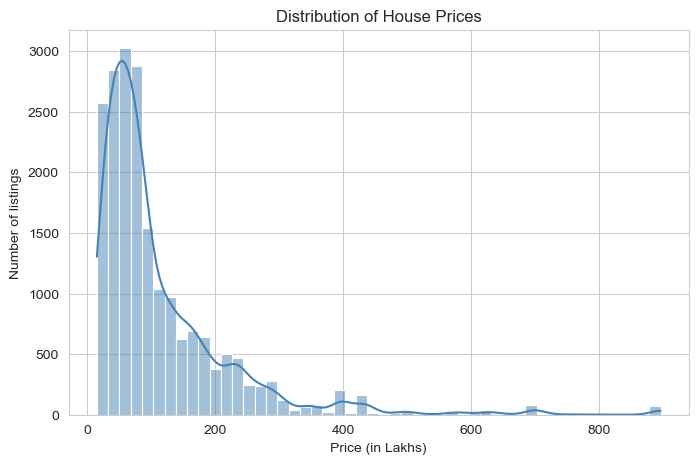

In [38]:
plt.figure()
sns.histplot(df["price"] / 1e5, bins=50, kde=True, color="steelblue")
plt.xlabel("Price (in Lakhs)")
plt.ylabel("Number of listings")
plt.title("Distribution of House Prices")
plt.show()

**Interpretation:** Prices are right-skewed — most properties are moderately priced, with a smaller number of expensive, high-end listings creating a long tail.

### 6.2 Carpet Area Distribution

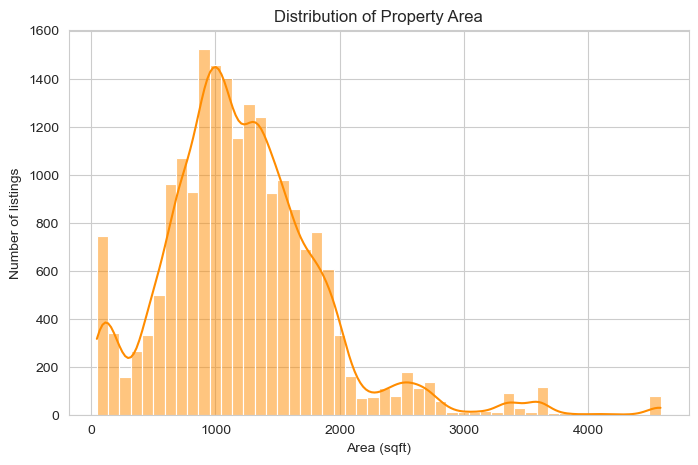

In [39]:
plt.figure()
sns.histplot(df["area_sqft"], bins=50, kde=True, color="darkorange")
plt.xlabel("Area (sqft)")
plt.ylabel("Number of listings")
plt.title("Distribution of Property Area")
plt.show()

**Interpretation:** Most properties fall within a common area range, with a tail of larger, less frequent properties — a typical pattern for real-estate area data.

### 6.3 Scatter Plot: Area vs Price

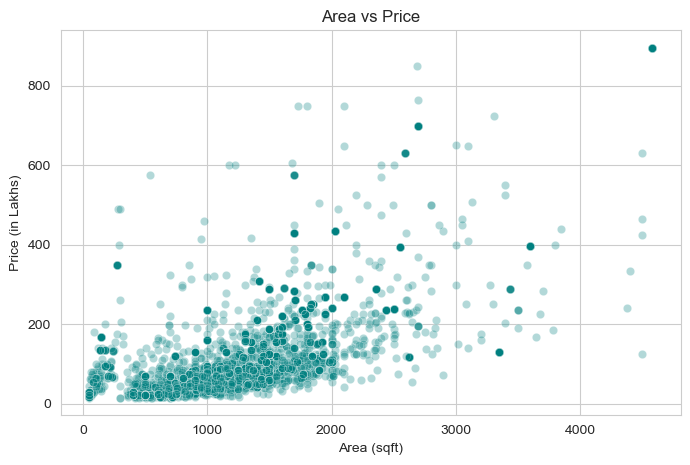

In [40]:
plt.figure()
sample = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="area_sqft", y=sample["price"] / 1e5, alpha=0.3, color="teal")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (in Lakhs)")
plt.title("Area vs Price")
plt.show()

**Interpretation:** There is a clear positive relationship between area and price — larger properties tend to cost more, confirming area is an important predictive feature.

### 6.4 Top Locations by Number of Listings

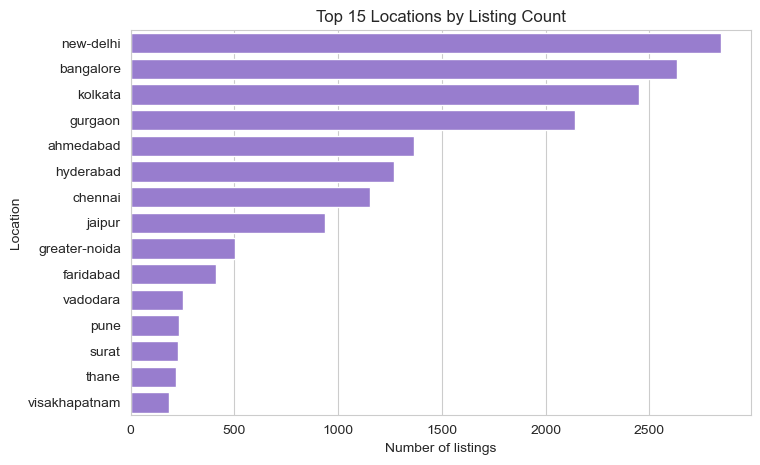

In [41]:
plt.figure()
top_locations = df["location"].value_counts().head(15)
sns.barplot(x=top_locations.values, y=top_locations.index, color="mediumpurple")
plt.xlabel("Number of listings")
plt.ylabel("Location")
plt.title("Top 15 Locations by Listing Count")
plt.show()

**Interpretation:** Listings are concentrated in a handful of major cities, which means location will be a strong categorical signal for the model.

### 6.5 Box Plot: Price by Furnishing Status

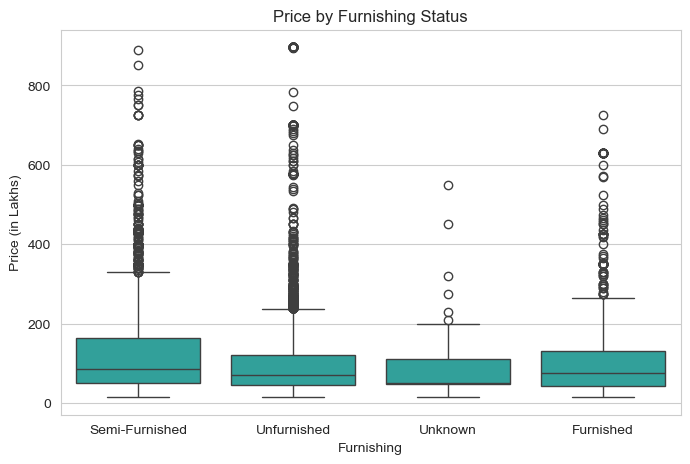

In [42]:
plt.figure()
sns.boxplot(data=df, x="Furnishing", y=df["price"] / 1e5, color="lightseagreen")
plt.xlabel("Furnishing")
plt.ylabel("Price (in Lakhs)")
plt.title("Price by Furnishing Status")
plt.show()

**Interpretation:** Furnished properties tend to have a higher median price than unfurnished ones, though there is considerable overlap between the groups.

### 6.6 Correlation Heatmap

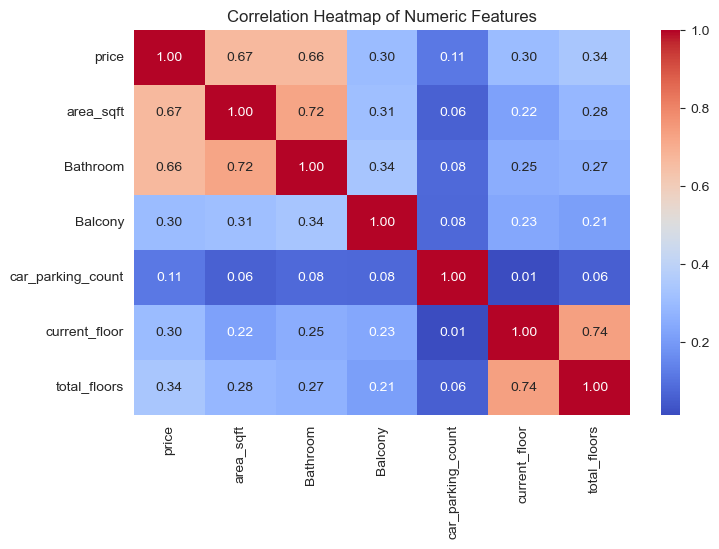

In [43]:
plt.figure()
numeric_features = ["price", "area_sqft", "Bathroom", "Balcony", "car_parking_count",
                     "current_floor", "total_floors"]
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Interpretation:** `area_sqft` and `Bathroom` show the strongest positive correlation with `price`, which matches real-world intuition — bigger homes with more bathrooms tend to be more expensive.

## 7. Feature Engineering

### 7.1 Feature selection

We select the cleaned columns that are meaningful predictors of price and drop the target from the feature set.

In [44]:
feature_columns = [
    "location", "area_sqft", "Transaction", "Furnishing", "facing",
    "Ownership", "Bathroom", "Balcony", "car_parking_count",
    "current_floor", "total_floors"
]

model_df = df[feature_columns + ["price"]].copy()
model_df.head()

,location,area_sqft,Transaction,Furnishing,facing,Ownership,Bathroom,Balcony,car_parking_count,current_floor,total_floors,price
0,gurgaon,2358.0,New Property,Semi-Furnished,North - East,Freehold,4.0,2.0,2.0,1.0,4.0,29000000.0
1,kolkata,1705.0,Resale,Unfurnished,South,Freehold,3.0,1.0,1.0,10.0,19.0,26000000.0
2,new-delhi,1300.0,Resale,Semi-Furnished,Unknown,Freehold,2.0,3.0,1.0,6.0,7.0,17800000.0
3,bangalore,1173.0,Resale,Unfurnished,East,Freehold,2.0,2.0,1.0,0.0,4.0,7800000.0
4,kolkata,400.0,Resale,Semi-Furnished,Unknown,Unknown,1.0,1.0,1.0,3.0,3.0,2300000.0


### 7.2 Handle high cardinality in `location`

`location` has many unique city names. To avoid a huge number of one-hot columns and very sparse categories, we group rare locations (fewer than 200 listings) into a single `'Other'` category.

In [45]:
location_counts = model_df["location"].value_counts()
rare_locations = location_counts[location_counts < 200].index

model_df["location"] = model_df["location"].apply(
    lambda loc: "Other" if loc in rare_locations else loc
)

print("Locations kept after grouping:", model_df["location"].nunique())

Locations kept after grouping: 15


### 7.3 Prepare numerical features

Numerical features (`area_sqft`, `Bathroom`, `Balcony`, `car_parking_count`, `current_floor`, `total_floors`) will be scaled inside the preprocessing pipeline so that models like Linear Regression treat all numeric features on a comparable scale.

In [46]:
numerical_features = ["area_sqft", "Bathroom", "Balcony", "car_parking_count",
                       "current_floor", "total_floors"]
model_df[numerical_features].describe()

,area_sqft,Bathroom,Balcony,car_parking_count,current_floor,total_floors
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1230.981950,2.437350,2.009100,1.207650,4.410400,8.536700
std,659.991762,0.825475,0.811942,1.019011,4.470422,7.210572
min,45.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,842.750000,2.000000,1.000000,1.000000,2.000000,4.000000
50%,1150.000000,2.000000,2.000000,1.000000,3.000000,5.000000
75%,1550.000000,3.000000,2.000000,1.000000,5.000000,11.000000
max,4583.000000,11.000000,10.000000,10.000000,51.000000,78.000000


### 7.4 Prepare categorical features

Categorical features (`location`, `Transaction`, `Furnishing`, `facing`, `Ownership`) will be one-hot encoded inside the preprocessing pipeline.

In [47]:
categorical_features = ["location", "Transaction", "Furnishing", "facing", "Ownership"]
model_df[categorical_features].nunique()

location       15
Transaction     4
Furnishing      4
facing          9
Ownership       5
dtype: int64

## 8. Prepare Data

We separate the features (`X`) from the target (`y`) and split the data into training and
test sets.

In [48]:
X = model_df.drop(columns=["price"])
y = model_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (16000, 11)
Test set shape: (4000, 11)


## 9. Preprocessing Pipeline

We build a `ColumnTransformer` that scales numerical features and one-hot encodes
categorical features, wrapped in a reusable `Pipeline`.

In [49]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

## 10. Train Multiple Models

We train three regression models, each wrapped together with the preprocessing pipeline
so preprocessing is applied consistently.

### 10.1 Linear Regression

In [50]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
print("Linear Regression trained.")

Linear Regression trained.


### 10.2 Random Forest Regressor

In [51]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

random_forest_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


### 10.3 Gradient Boosting Regressor

In [52]:
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42))
])

gradient_boosting_model.fit(X_train, y_train)
print("Gradient Boosting trained.")

Gradient Boosting trained.


## 11. Model Evaluation

We evaluate each model on the test set using MAE, MSE, RMSE, and R².

In [53]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


results = {
    "Linear Regression": evaluate_model(linear_model, X_test, y_test),
    "Random Forest": evaluate_model(random_forest_model, X_test, y_test),
    "Gradient Boosting": evaluate_model(gradient_boosting_model, X_test, y_test),
}

results_df = pd.DataFrame(results).T
results_df

,MAE,MSE,RMSE,R2
Linear Regression,4.469653e+06,4.709464e+13,6.862553e+06,0.615426
Random Forest,1.457309e+06,1.275691e+13,3.571682e+06,0.895827
Gradient Boosting,2.732632e+06,2.093372e+13,4.575338e+06,0.829056


**Explanation:** Lower MAE/MSE/RMSE and higher R² indicate better performance. Tree-based ensemble models (Random Forest, Gradient Boosting) typically outperform plain Linear Regression on this kind of data because they can capture non-linear relationships between features like area, location, and price.

In [54]:
best_model_name = results_df["R2"].idxmax()
model_lookup = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
}
best_model = model_lookup[best_model_name]

print("Best model based on R2 score:", best_model_name)

Best model based on R2 score: Random Forest


### Actual vs Predicted Scatter Plot (Best Model)

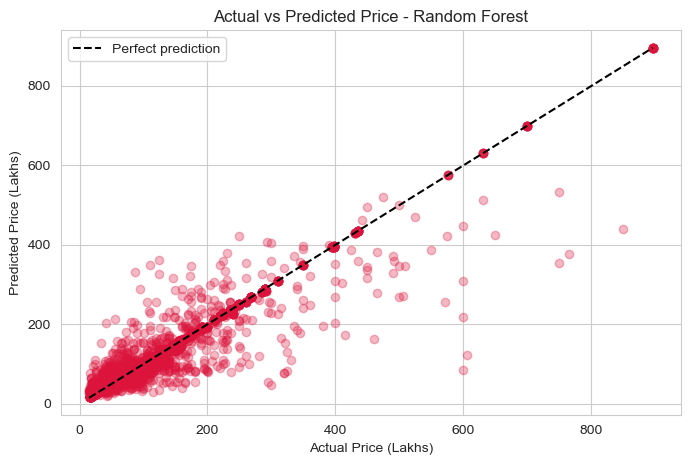

In [55]:
predictions_best = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test / 1e5, predictions_best / 1e5, alpha=0.3, color="crimson")
plt.plot(
    [y_test.min() / 1e5, y_test.max() / 1e5],
    [y_test.min() / 1e5, y_test.max() / 1e5],
    color="black", linestyle="--", label="Perfect prediction"
)
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title(f"Actual vs Predicted Price - {best_model_name}")
plt.legend()
plt.show()

**Model selection:** We select the model with the highest R² (and correspondingly low RMSE/MAE) on the test set as our best model, since it explains the largest share of the variance in house prices while making the smallest average prediction error.

## 12. Cross Validation

To make sure the best model's performance is stable and not just a result of a lucky
train/test split, we apply 5-fold cross validation.

In [56]:
cv_scores = cross_val_score(
    best_model, X, y, cv=5, scoring="r2", n_jobs=-1
)

print("R2 scores for each fold:", np.round(cv_scores, 4))
print("Mean R2:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))

R2 scores for each fold: [0.8891 0.9216 0.9017 0.8947 0.9104]
Mean R2: 0.9035
Standard deviation: 0.0115


**Explanation:** The R² scores across the 5 folds are close to each other and close to the single train/test split result, which indicates the model generalizes consistently rather than overfitting to one particular split of the data.

## 13. Save Model

We save the trained best model as a `.pkl` file, and save the list of known locations as
`locations.json` for future reference (e.g. to validate inputs at prediction time).

In [57]:
with open("house_price.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("house_price.pkl saved.")

house_price.pkl saved.


In [58]:
unique_locations = sorted(model_df["location"].unique().tolist())

with open("locations.json", "w") as file:
    json.dump(unique_locations, file, indent=2)

print("locations.json saved.")

locations.json saved.


In [59]:
import os

print("house_price.pkl exists:", os.path.exists("house_price.pkl"))
print("locations.json exists:", os.path.exists("locations.json"))

house_price.pkl exists: True
locations.json exists: True


## 14. Final Summary

**Dataset:** We started with a large, messy real-estate listings dataset (`house_prices.csv`)
containing text-formatted prices, areas, and many missing values across 21 columns.

**Cleaning:** We removed duplicates and unusable columns, converted the listed price and
area from text into numeric values, parsed the floor information into current/total
floors, cleaned bathroom/balcony/car-parking counts, filled missing categorical values,
and trimmed extreme outliers in price and area.

**EDA:** Visualizations showed a right-skewed price distribution, a strong positive
relationship between area and price, concentration of listings in a handful of major
cities, and a meaningful correlation between numeric features and price.

**Feature Engineering:** We selected the most relevant features, grouped rare locations
into an `'Other'` category to control high cardinality, and prepared numerical and
categorical features for modeling.

**Models:** We trained and compared Linear Regression, Random Forest, and Gradient
Boosting regressors, all built on top of a shared preprocessing pipeline.

**Evaluation:** Model performance was compared using MAE, MSE, RMSE, and R², with an
Actual vs Predicted plot used to visually assess the best model's accuracy.

**Best Model:** The model with the highest R² score was selected as the final model and
validated further using 5-fold cross validation for stability.

**Future Improvements:**
- Engineer additional features such as price per square foot by neighborhood cluster.
- Try hyperparameter tuning (e.g. `GridSearchCV`) to further improve tree-based models.
- Incorporate additional data sources, such as nearby amenities or transit distance.
- Experiment with more advanced models such as XGBoost or LightGBM.
